## Validation — Holdout 10% Evaluation

Independent evaluation of the classification model pipeline.  
- Input: CLR-transformed genus profiles (preprocessing completed in `preprocessing.ipynb`)  
- Pipeline: feature selection → model.predict  
- Data: 10% holdout validation set from the seed-42 split

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report,
                             r2_score, mean_absolute_error, mean_squared_error)
import warnings
warnings.filterwarnings('ignore')

CODE_DIR = "/home/admin-01/taeho/BRL_chicken/revision/code"
DATA_DIR = f"{CODE_DIR}/data"
PKL_DIR  = f"{DATA_DIR}/pkl"
VAL_DIR  = f"{DATA_DIR}/val_figures"

import os
os.makedirs(VAL_DIR, exist_ok=True)

LABEL_SEED  = 42
LABEL_ORDER = [0, 2, 1]   # Early → Intermediate → Late
LABEL_NAMES = {0: 'Early', 1: 'Late', 2: 'Intermediate'}

C_EARLY    = '#1f77b4'
C_INTER   = '#ff7f0e'
C_LATE = '#9467bd'

## 1. Pipeline & Data Load

- `best_model_pipeline.pkl` — Classification model (Optuna × FC Top10 × RF)
- `best_reg_pipeline.pkl` — Regression model (Optuna × FC Top10 × RF, Early + Intermediate only)
- `labeled_splits.pkl` — CLR-preprocessed validation set

In [2]:
# ── Classification pipeline ───────────────────────────────────────
with open(f"{PKL_DIR}/best_model_pipeline.pkl", 'rb') as f:
    clf_pipe = pickle.load(f)

clf_model      = clf_pipe['model']
clf_feats      = clf_pipe['features']
clf_cond_label = clf_pipe['cond_label']
clf_model_name = clf_pipe['model_name']

# ── Regression pipeline ───────────────────────────────────────────
with open(f"{PKL_DIR}/best_reg_pipeline.pkl", 'rb') as f:
    reg_pipe = pickle.load(f)

reg_model      = reg_pipe['model']
reg_feats      = reg_pipe['features']
reg_cond_label = reg_pipe['cond_label']
reg_model_name = reg_pipe['model_name']
tpc_col        = reg_pipe['tpc_col']

# ── Val splits ────────────────────────────────────────────────────
with open(f"{PKL_DIR}/{clf_pipe['splits_pkl']}", 'rb') as f:
    d = pickle.load(f)
splits = d['labeled_splits']
val_df = splits[LABEL_SEED]['val']

print(f"Classification : {clf_cond_label} / {clf_model_name}")
print(f"Regression     : {reg_cond_label} / {reg_model_name}")
print(f"\nVal set (seed={LABEL_SEED}): {len(val_df)} samples")
print(val_df['Label'].map(LABEL_NAMES).value_counts().rename('count').to_string())
print(f"\nCLR features : {len([c for c in val_df.columns if c.startswith('g__')])}")
print(f"Clf features : {len(clf_feats)}")
print(f"Reg features : {len(reg_feats)}")

Classification : Optuna × FC Top10 / RandomForest
Regression     : Optuna × FC Top10 / RandomForest

Val set (seed=42): 27 samples
Label
Early           14
Intermediate    10
Late             3

CLR features : 110
Clf features : 10
Reg features : 10


## 2. Preprocessing — CLR Transformation Verification

Centered Log-Ratio (CLR) transformation is the standard approach for comparing relative abundances in compositional data.  
Applied per-sample to all 270 samples in `preprocessing.ipynb` and stored in `splits.pkl` — no data leakage.

**CLR formula**  
$$x_i^{CLR} = \ln\left(\frac{x_i}{g(\mathbf{x})}\right), \quad g(\mathbf{x}) = \left(\prod_{j=1}^{D} x_j\right)^{1/D}$$

Verify that CLR-transformed values are already present in the validation set.

In [3]:
genus_cols = [c for c in val_df.columns if c.startswith('g__')]
clr_vals   = val_df[genus_cols].values

print("=== CLR 변환 확인 ===")
print(f"Feature 수     : {len(genus_cols)}")
print(f"값 범위        : [{clr_vals.min():.3f}, {clr_vals.max():.3f}]")
print(f"음수 포함 여부 : {(clr_vals < 0).any()} (CLR 정상)")
print(f"샘플별 합계 (첫 3행): {clr_vals[:3].sum(axis=1).round(6)}")  # 0에 가까워야 함
print(f"\n분류 입력 feature 예시 (첫 3행):")
print(val_df[clf_feats].head(3).to_string())

=== CLR 변환 확인 ===
Feature 수     : 110
값 범위        : [-9.569, 16.705]
음수 포함 여부 : True (CLR 정상)
샘플별 합계 (첫 3행): [-23.341076 -28.695312  11.234816]

분류 입력 feature 예시 (첫 3행):
   g__Iodobacter  g__Carnobacterium  g__Vagococcus  g__Hafnia-Obesumbacterium  g__Bacillus  g__Macrococcus  g__Streptococcus  g__Xanthomonas  g__Staphylococcus  g__Aeromonas
0      -3.618327           2.426146      -3.618327                   5.335866    10.727474       11.243108         11.191436       10.259877          11.206474     10.200454
1      -5.645138           1.351460       1.020576                   5.302545     9.318928        9.354330          8.795257        8.674142           8.059385      8.728435
2      -2.247884          -1.965899      -1.059112                  -0.563624     5.303450        5.365965          3.810306        5.313955           4.851099      3.267639


## 3. Classification Validation

**Model**: Optuna × FC Top10 × Random Forest (trained on seed-42)  
**Input**: FC Top10 features extracted from the CLR-transformed validation set  
**Evaluation**: Accuracy, F1-macro, Confusion Matrix, Per-class Report

=== Classification — Val Set (seed=42) ===
Accuracy  : 0.815
F1-macro  : 0.767

              precision    recall  f1-score   support

       Early       0.87      0.93      0.90        14
Intermediate       0.78      0.70      0.74        10
        Late       0.67      0.67      0.67         3

    accuracy                           0.81        27
   macro avg       0.77      0.77      0.77        27
weighted avg       0.81      0.81      0.81        27



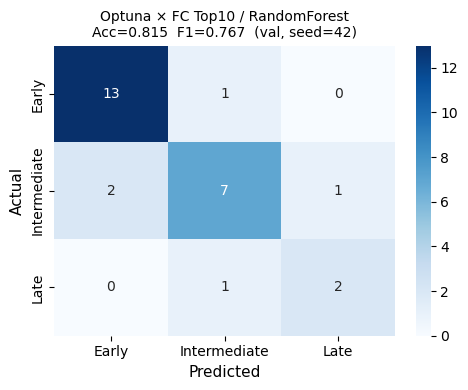

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/val_figures/val_clf_confusion.png


In [4]:
X_val  = val_df[clf_feats].values
y_val  = val_df['Label'].values
y_pred = clf_model.predict(X_val)

acc = accuracy_score(y_val, y_pred)
f1  = f1_score(y_val, y_pred, average='macro', zero_division=0)

target_names = [LABEL_NAMES[l] for l in LABEL_ORDER]
print(f"=== Classification — Val Set (seed={LABEL_SEED}) ===")
print(f"Accuracy  : {acc:.3f}")
print(f"F1-macro  : {f1:.3f}")
print()
print(classification_report(y_val, y_pred,
                             labels=LABEL_ORDER,
                             target_names=target_names,
                             zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_val, y_pred, labels=LABEL_ORDER)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title(f"{clf_cond_label} / {clf_model_name}\n"
             f"Acc={acc:.3f}  F1={f1:.3f}  (val, seed={LABEL_SEED})",
             fontsize=10)
fig.tight_layout()
fig.savefig(f"{VAL_DIR}/val_clf_confusion.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VAL_DIR}/val_clf_confusion.png")

## 4. End-to-End — Classification → TPC Regression

A practical two-stage pipeline connecting classification predictions to regression input.  
Samples predicted as Late by the classifier are excluded from regression.  
Late samples misclassified as Early or Intermediate are passed to the regression model as-is —
as out-of-distribution inputs, the model tends to predict high TPC values for these cases (treated as outliers).

Scatter plot colors reflect true labels.

=== Step 1: Classification ===
  Early       true=14  pred=15
  Intermediate  true=10  pred=9
  Late        true=3  pred=3

=== Step 2: Regression (predicted Early+Intermediate, n=24) ===
R²   : 0.757
MAE  : 0.471  log CFU/g
RMSE : 0.566  log CFU/g


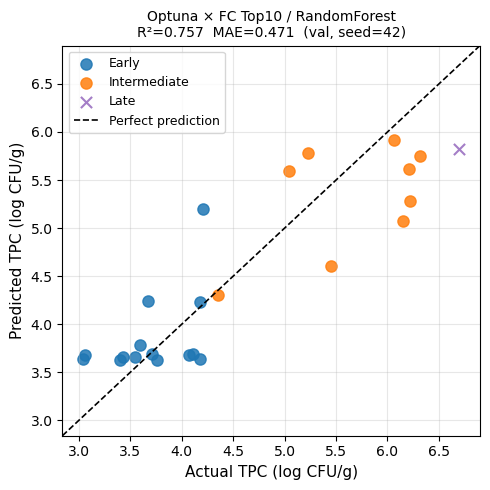

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/val_figures/val_e2e_scatter.png


In [5]:
# ── Step 1: Classification ────────────────────────────────────────
X_val  = val_df[clf_feats].values
y_val  = val_df['Label'].values
y_pred = clf_model.predict(X_val)

print("=== Step 1: Classification ===")
for lbl in LABEL_ORDER:
    n_true = (y_val == lbl).sum()
    n_pred = (y_pred == lbl).sum()
    print(f"  {LABEL_NAMES[lbl]:10s}  true={n_true}  pred={n_pred}")

 # ── Step 2: 예측 Early+Intermediate만 회귀 입력 ──────────────────────────
fm_mask    = pd.Series(y_pred).isin([0, 2]).values
val_reg    = val_df[fm_mask].copy()
y_pred_reg = reg_model.predict(val_reg[reg_feats].values)
y_true_reg = val_reg[tpc_col].values

r2   = r2_score(y_true_reg, y_pred_reg)
mae  = mean_absolute_error(y_true_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_true_reg, y_pred_reg))

print(f"\n=== Step 2: Regression (predicted Early+Intermediate, n={len(val_reg)}) ===")
print(f"R²   : {r2:.3f}")
print(f"MAE  : {mae:.3f}  log CFU/g")
print(f"RMSE : {rmse:.3f}  log CFU/g")

# ── Scatter: 실제 label 색으로 구분 ──────────────────────────────────
colors_map = {0: C_EARLY, 2: C_INTER, 1: C_LATE}
true_labels_reg = val_reg['Label'].values

mn_v = min(y_true_reg.min(), y_pred_reg.min()) - 0.2
mx_v = max(y_true_reg.max(), y_pred_reg.max()) + 0.2

fig, ax = plt.subplots(figsize=(5, 5))
for lbl in LABEL_ORDER:
    mask = true_labels_reg == lbl
    if mask.any():
        ax.scatter(y_true_reg[mask], y_pred_reg[mask],
                   color=colors_map[lbl], label=LABEL_NAMES[lbl],
                   alpha=0.85, s=65,
                   marker='x' if lbl == 1 else 'o')   # Spoilage는 x 마커

ax.plot([mn_v, mx_v], [mn_v, mx_v], 'k--', lw=1.2, label='Perfect prediction')
ax.set_xlim(mn_v, mx_v); ax.set_ylim(mn_v, mx_v)
ax.set_xlabel('Actual TPC (log CFU/g)', fontsize=11)
ax.set_ylabel('Predicted TPC (log CFU/g)', fontsize=11)
ax.set_title(f"{reg_cond_label} / {reg_model_name}\n"
             f"R²={r2:.3f}  MAE={mae:.3f}  (val, seed={LABEL_SEED})", fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(f"{VAL_DIR}/val_e2e_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VAL_DIR}/val_e2e_scatter.png")

## 5. Summary

**Holdout validation set (seed-42, n = 27): Early = 14 / Intermediate = 10 / Late = 3**

| Stage | Model | Metric | Validation Result |
|---|---|---|---|
| Classification | Optuna × FC Top10 × RF | Accuracy | **0.815** |
| | | F1-macro | **0.767** |
| Regression (End-to-End) | Optuna × FC Top10 × RF | R² | **0.757** |
| | | MAE | **0.471 log CFU/g** |
| | | RMSE | **0.566 log CFU/g** |

---

### Classification — Interpretation

- **Early F1 = 0.90**: High accuracy in identifying samples within the freshness-preserved range → minimizes false Late alarms, helping prevent unnecessary product discard
- **Intermediate F1 = 0.74**: Lowest performance among the three classes. The Intermediate stage represents a transitional zone between Early and Late, where microbial community shifts are gradual → class overlap makes boundary discrimination inherently difficult. Reduced Intermediate sample size following leakage removal (n = 62 / 270) also contributes.
- **Late F1 = 0.67**: One of three Late samples misclassified (predicted as Intermediate). Statistical reliability is low given Late n = 3 in the validation set — interpret with caution. From an operational standpoint, however, misclassifying Late as Intermediate is less harmful than misclassifying Intermediate as Late (conservative error direction).

---

### Regression (End-to-End) — Interpretation

- 24 samples predicted as Early or Intermediate by the classifier were passed to the regression model (including 1 true Late sample).
- **R² = 0.757**: The model explains 75.7% of TPC variance in the validation set. A marginal improvement over the 10-seed test set mean R² = 0.71 confirms that generalization performance is maintained on an honest, leakage-free holdout.
- **MAE = 0.471 log CFU/g**: Mean TPC prediction error of 0.47 log CFU/g. In food microbiology, errors within 0.5 log units are generally considered acceptable for practical application.
- **Effect of the misclassified Late sample**: True TPC ≈ 6.7 log CFU/g (high load); the model predicted a value exceeding the Early/Intermediate training range (4.2–6.4) — naturally outputting a high TPC as an out-of-distribution response. This demonstrates that classification errors are handled safely at the regression stage.

---

In [6]:
print("=" * 55)
print("VALIDATION SUMMARY  (seed=42 holdout, n=27)")
print("=" * 55)

print(f"\n[Classification]  {clf_cond_label} / {clf_model_name}")
print(f"  Accuracy  : {acc:.3f}")
print(f"  F1-macro  : {f1:.3f}")

print(f"\n[Regression — End-to-End]  {reg_cond_label} / {reg_model_name}")
print(f"  N (pred Early+Intermediate) : {len(val_reg)}")
print(f"  R²    : {r2:.3f}")
print(f"  MAE   : {mae:.3f}  log CFU/g")
print(f"  RMSE  : {rmse:.3f}  log CFU/g")

# 결과 저장
val_summary = {
    'clf_acc':  acc,
    'clf_f1':   f1,
    'e2e_n':    len(val_reg),
    'e2e_r2':   r2,
    'e2e_mae':  mae,
    'e2e_rmse': rmse,
}
with open(f"{PKL_DIR}/validation_results.pkl", 'wb') as f:
    pickle.dump(val_summary, f)
print(f"\nSaved → {PKL_DIR}/validation_results.pkl")

VALIDATION SUMMARY  (seed=42 holdout, n=27)

[Classification]  Optuna × FC Top10 / RandomForest
  Accuracy  : 0.815
  F1-macro  : 0.767

[Regression — End-to-End]  Optuna × FC Top10 / RandomForest
  N (pred Early+Intermediate) : 24
  R²    : 0.757
  MAE   : 0.471  log CFU/g
  RMSE  : 0.566  log CFU/g

Saved → /home/admin-01/taeho/BRL_chicken/revision/code/data/pkl/validation_results.pkl


## Validation SHAP

shap_values np.array shape : (27, 10, 3)
X_val_clf shape            : (27, 10)
class_order                : [0, 1, 2] → ['Early', 'Late', 'Intermediate']
[Early] sv.shape=(27, 10)


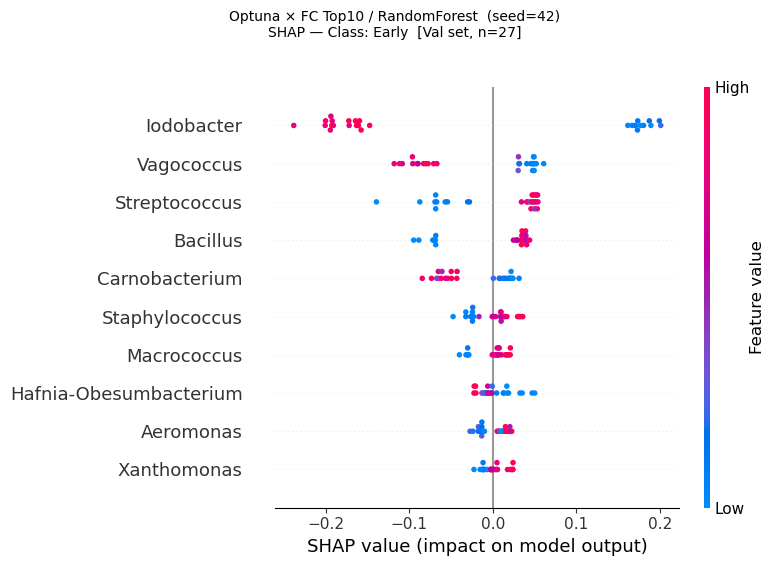

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/val_figures/val_clf_shap_early.png
[Late] sv.shape=(27, 10)


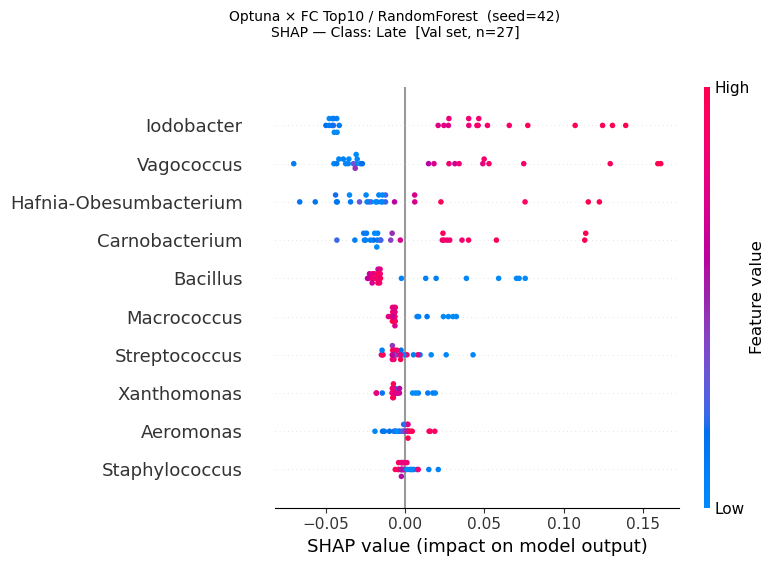

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/val_figures/val_clf_shap_late.png
[Intermediate] sv.shape=(27, 10)


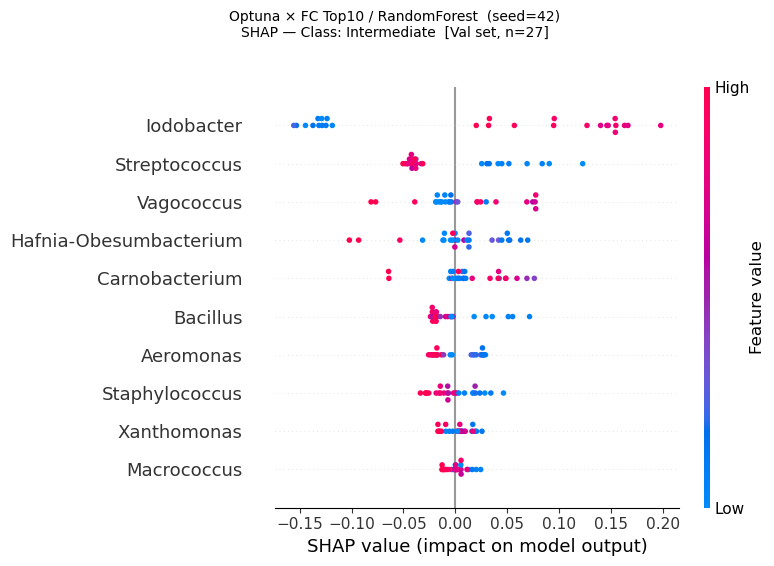

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/val_figures/val_clf_shap_intermediate.png


In [7]:
import shap
import numpy as np

VAL_SHAP_DIR = f"{DATA_DIR}/val_figures"
os.makedirs(VAL_SHAP_DIR, exist_ok=True)

short_names = [f.replace('g__', '') for f in clf_feats]
X_val_clf   = pd.DataFrame(val_df[clf_feats].values, columns=short_names)

explainer   = shap.TreeExplainer(clf_model)
shap_values = explainer.shap_values(X_val_clf)

class_order = clf_model.classes_.tolist()
class_names = [LABEL_NAMES[c] for c in class_order]
n_samples, n_feats = X_val_clf.shape

# ── shape 진단 ──────────────────────────────────────────────────
sv_arr = np.array(shap_values)
print(f"shap_values np.array shape : {sv_arr.shape}")
print(f"X_val_clf shape            : {X_val_clf.shape}")
print(f"class_order                : {class_order} → {class_names}")

# ── 클래스별 SHAP 추출 함수 ─────────────────────────────────────
def get_class_sv(sv_arr, class_idx, n_cls, n_samp, n_feat):
    if sv_arr.ndim == 3:
        # (n_cls, n_samp, n_feat)
        if sv_arr.shape[0] == n_cls and sv_arr.shape[1] == n_samp:
            return sv_arr[class_idx]
        # (n_samp, n_feat, n_cls)
        if sv_arr.shape[0] == n_samp and sv_arr.shape[2] == n_cls:
            return sv_arr[:, :, class_idx]
        # (n_cls, n_samp, n_feat+1)
        if sv_arr.shape[0] == n_cls:
            return sv_arr[class_idx, :, :n_feat]
    # list-like fallback
    s = sv_arr[class_idx]
    return s[:, :n_feat] if s.shape[1] > n_feat else s

n_cls = len(class_order)

# ── 클래스별 Summary plot ──────────────────────────────────────
for idx, cls_name in enumerate(class_names):
    sv = get_class_sv(sv_arr, idx, n_cls, n_samples, n_feats)
    print(f"[{cls_name}] sv.shape={sv.shape}")

    shap.summary_plot(sv, X_val_clf, show=False, plot_type='dot', color_bar=True)
    plt.gcf().suptitle(
        f"{clf_cond_label} / {clf_model_name}  (seed={LABEL_SEED})\n"
        f"SHAP — Class: {cls_name}  [Val set, n={n_samples}]",
        fontsize=10, y=1.02)
    plt.tight_layout()
    path = f"{VAL_SHAP_DIR}/val_clf_shap_{cls_name.lower()}.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

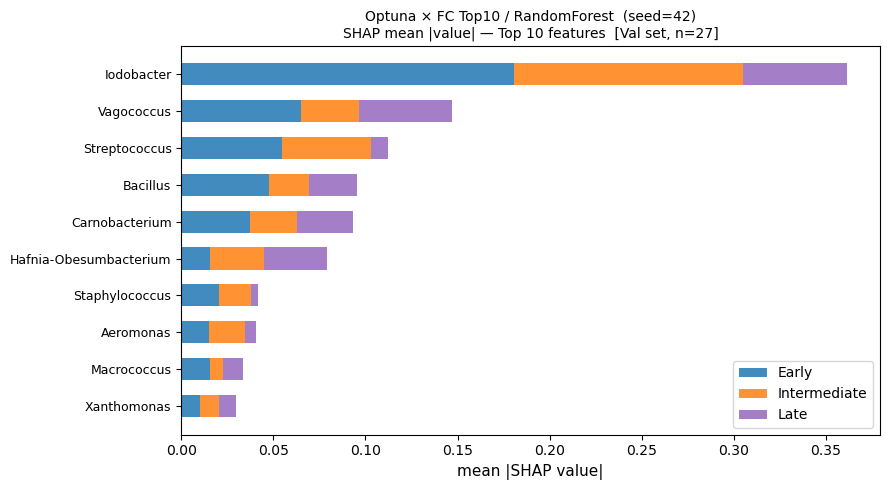

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/val_figures/val_clf_shap_bar.png


In [8]:
# ── Stacked bar: class별 mean|SHAP| ──────────────────────────────
C_EARLY    = '#1f77b4'
C_INTER   = '#ff7f0e'
C_LATE = '#9467bd'
LABEL_ORDER = [0, 2, 1]   # Early → Intermediate → Late
colors_map  = {0: C_EARLY, 2: C_INTER, 1: C_LATE}
name_map    = {0: 'Early', 2: 'Intermediate', 1: 'Late'}

top_n = min(10, n_feats)

means = {}
for lbl in LABEL_ORDER:
    col = class_order.index(lbl)
    sv  = get_class_sv(sv_arr, col, n_cls, n_samples, n_feats)
    means[lbl] = np.mean(np.abs(sv), axis=0)   # (n_feats,)

total   = sum(means[lbl] for lbl in LABEL_ORDER)
top_idx = np.argsort(total)[-top_n:][::-1]
feat_labels = [short_names[i] for i in top_idx]

y = np.arange(len(top_idx))
fig, ax = plt.subplots(figsize=(9, max(5, 0.4 * top_n)))
lefts = np.zeros(len(top_idx))
for lbl in LABEL_ORDER:
    vals = np.array([means[lbl][i] for i in top_idx])
    ax.barh(y, vals, left=lefts, height=0.6,
            color=colors_map[lbl], label=name_map[lbl], alpha=0.85)
    lefts += vals

ax.set_yticks(y)
ax.set_yticklabels(feat_labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('mean |SHAP value|', fontsize=11)
ax.set_title(
    f"{clf_cond_label} / {clf_model_name}  (seed={LABEL_SEED})\n"
    f"SHAP mean |value| — Top {top_n} features  [Val set, n={n_samples}]",
    fontsize=10)
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
bar_path = f"{VAL_SHAP_DIR}/val_clf_shap_bar.png"
fig.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {bar_path}")

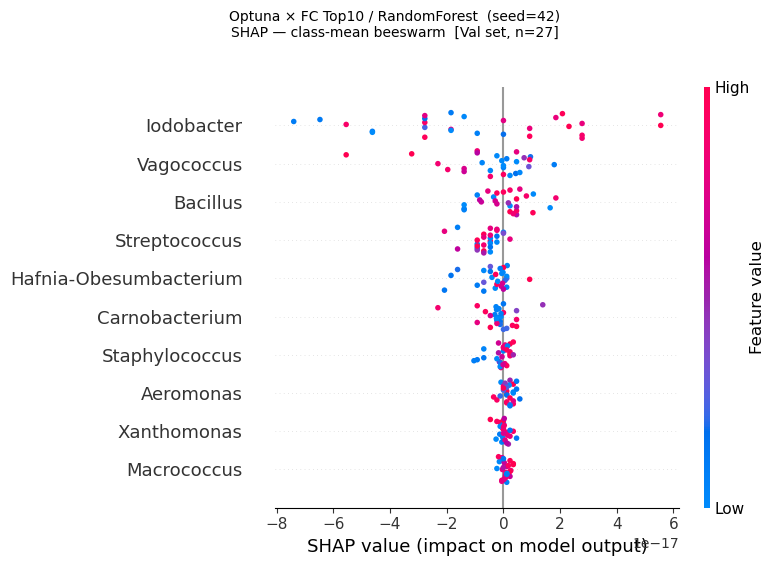

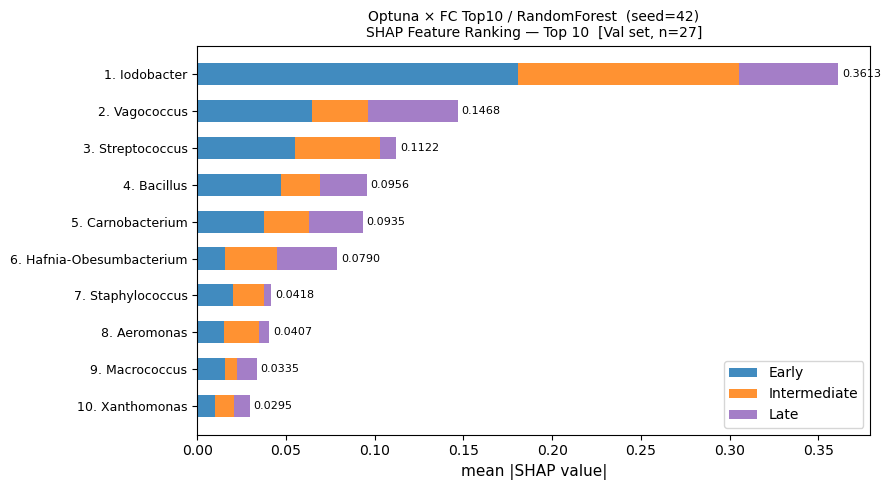

Saved: val_clf_shap_beeswarm.png, val_clf_shap_ranking_bar.png


In [9]:
# ── Combined beeswarm: 클래스 평균 SHAP ──────────────────────────
sv_stack = np.stack([
    get_class_sv(sv_arr, idx, n_cls, n_samples, n_feats)
    for idx in range(n_cls)
], axis=0)                                          # (n_cls, n_samples, n_feats)

mean_abs_per_feat = np.mean(np.abs(sv_stack), axis=(0, 1))   # (n_feats,)
top_idx   = np.argsort(mean_abs_per_feat)[::-1][:10]
top_names = [short_names[i] for i in top_idx]

mean_sv_top = np.mean(sv_stack, axis=0)[:, top_idx]
X_top = pd.DataFrame(X_val_clf.values[:, top_idx], columns=top_names)

shap.summary_plot(mean_sv_top, X_top, show=False, plot_type='dot', color_bar=True)
plt.gcf().suptitle(
    f"{clf_cond_label} / {clf_model_name}  (seed={LABEL_SEED})\n"
    f"SHAP — class-mean beeswarm  [Val set, n={n_samples}]",
    fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(f"{VAL_SHAP_DIR}/val_clf_shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Ranking bar chart ──────────────────────────────────────────────
colors_map = {0: C_EARLY, 2: C_INTER, 1: C_LATE}
name_map   = {0: 'Early', 2: 'Intermediate', 1: 'Late'}

class_means = {}
for lbl in LABEL_ORDER:
    col_i = class_order.index(lbl)
    sv_cls = get_class_sv(sv_arr, col_i, n_cls, n_samples, n_feats)
    class_means[lbl] = np.mean(np.abs(sv_cls), axis=0)   # (n_feats,)

rank_labels = [f"{r+1}. {top_names[r]}" for r in range(len(top_idx))]
y = np.arange(len(top_idx))

fig, ax = plt.subplots(figsize=(9, max(5, 0.45 * len(top_idx))))
lefts = np.zeros(len(top_idx))
for lbl in LABEL_ORDER:
    vals = np.array([class_means[lbl][i] for i in top_idx])
    ax.barh(y, vals, left=lefts, height=0.6,
            color=colors_map[lbl], label=name_map[lbl], alpha=0.85)
    lefts += vals

# 총합 값 우측에 표시
for r, total_val in enumerate(lefts):
    ax.text(total_val + 0.002, r, f"{total_val:.4f}", va='center', fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(rank_labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('mean |SHAP value|', fontsize=11)
ax.set_title(
    f"{clf_cond_label} / {clf_model_name}  (seed={LABEL_SEED})\n"
    f"SHAP Feature Ranking — Top {len(top_idx)}  [Val set, n={n_samples}]",
    fontsize=10)
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig(f"{VAL_SHAP_DIR}/val_clf_shap_ranking_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: val_clf_shap_beeswarm.png, val_clf_shap_ranking_bar.png")


Val FM samples : 24  (Early=14, Intermediate=10)
Features       : ['Iodobacter', 'Carnobacterium', 'Vagococcus', 'Hafnia-Obesumbacterium', 'Bacillus', 'Macrococcus', 'Streptococcus', 'Xanthomonas', 'Staphylococcus', 'Aeromonas']


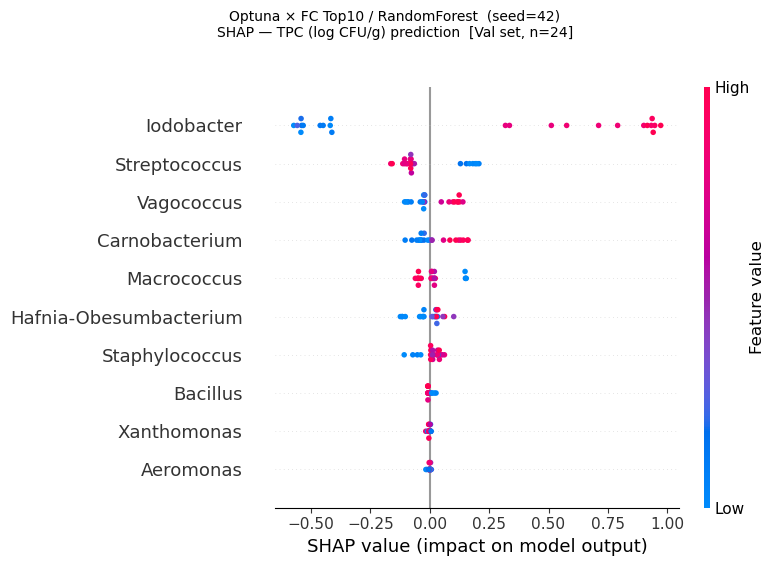

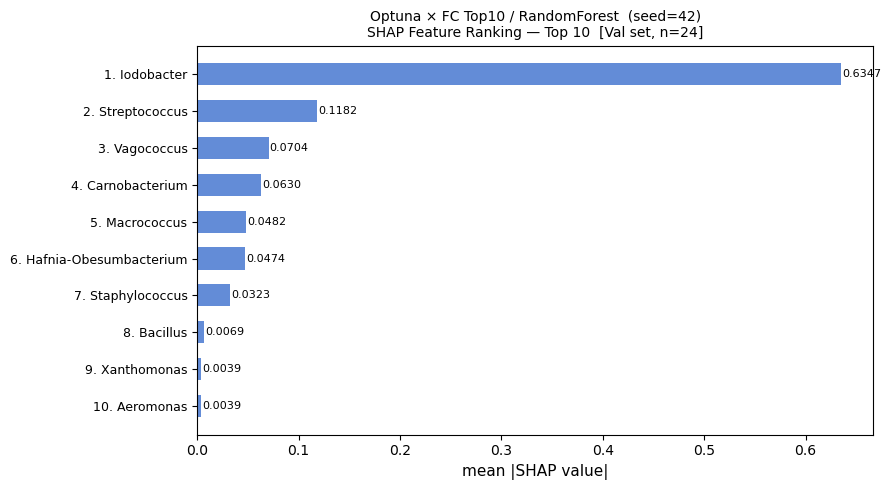

Saved: val_reg_shap_summary.png, val_reg_shap_ranking_bar.png


In [10]:
import shap

VAL_SHAP_DIR = f"{DATA_DIR}/val_figures"
os.makedirs(VAL_SHAP_DIR, exist_ok=True)

val_fm = val_df[val_df['Label'] != 1].copy()

short_names = [f.replace('g__', '') for f in reg_feats]
X_val_fm = pd.DataFrame(val_fm[reg_feats].values, columns=short_names)

print(f"Val FM samples : {len(val_fm)}  (Early={(val_fm['Label']==0).sum()}, Intermediate={(val_fm['Label']==2).sum()})")
print(f"Features       : {short_names}")

# ── Beeswarm ───────────────────────────────────────────────────────
explainer = shap.TreeExplainer(reg_model)
shap_vals = explainer.shap_values(X_val_fm)

shap.summary_plot(shap_vals, X_val_fm, show=False, plot_type='dot', color_bar=True)
plt.gcf().suptitle(
    f"{reg_cond_label} / {reg_model_name}  (seed={LABEL_SEED})\n"
    f"SHAP — TPC (log CFU/g) prediction  [Val set, n={len(val_fm)}]",
    fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(f"{VAL_SHAP_DIR}/val_reg_shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Ranking bar chart ──────────────────────────────────────────────
sv_arr_reg = np.array(shap_vals)
if sv_arr_reg.ndim == 1:
    sv_arr_reg = sv_arr_reg.reshape(1, -1)

mean_abs = np.mean(np.abs(sv_arr_reg), axis=0)   # (n_feats,)
top_idx  = np.argsort(mean_abs)[::-1][:10]

rank_labels = [f"{r+1}. {short_names[i]}" for r, i in enumerate(top_idx)]
vals = mean_abs[top_idx]
y    = np.arange(len(top_idx))

fig, ax = plt.subplots(figsize=(9, max(5, 0.45 * len(top_idx))))
ax.barh(y, vals, height=0.6, color='#4878d0', alpha=0.85)

for r, v in enumerate(vals):
    ax.text(v + 0.001, r, f"{v:.4f}", va='center', fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(rank_labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('mean |SHAP value|', fontsize=11)
ax.set_title(
    f"{reg_cond_label} / {reg_model_name}  (seed={LABEL_SEED})\n"
    f"SHAP Feature Ranking — Top {len(top_idx)}  [Val set, n={len(val_fm)}]",
    fontsize=10)
plt.tight_layout()
plt.savefig(f"{VAL_SHAP_DIR}/val_reg_shap_ranking_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: val_reg_shap_summary.png, val_reg_shap_ranking_bar.png")
